# Data Cleaaning and Preprocessing 

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(r'C:\Users\123\Downloads\Lead Scoring.csv')
# 1. Droping unique ID columns as they don't help in machine learning
df = df.drop(['Prospect ID', 'Lead Number'], axis=1)

# 2. Replace 'Select' with NaN (since 'Select' means nothing was chosen in the form)
df = df.replace('Select', np.nan)

# 3. Drop columns with more than 30% missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > 30].index
df = df.drop(cols_to_drop, axis=1)

print("Columns dropped due to high missing values:", list(cols_to_drop))
print("New Dataset Shape:", df.shape)

Columns dropped due to high missing values: ['Specialization', 'How did you hear about X Education', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']
New Dataset Shape: (9240, 25)


# Handeling Missing values & Feature Encoding

In [4]:
# Step 2 (Fixed): Handling Missing Values and Encoding Categorical Columns

# 1. Fill missing values for numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. Fill missing values for categorical columns with the mode (most frequent value)

cat_cols = df.select_dtypes(include=['object', 'str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:", df.isnull().sum().sum())

# 3. Convert categorical variables into numerical format using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

print("Updated Dataset Shape after Encoding:", df.shape)

Missing values after imputation: 0
Updated Dataset Shape after Encoding: (9240, 112)


# Model Training & Evaluation

In [5]:
# Step 3: Model Training and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Features (X) and Target (y)
# The target column is 'Converted'
X = df.drop('Converted', axis=1)
y = df['Converted']

# 2. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators = 100, max_depth = 5, random_state=42)
model.fit(X_train, y_train)
model


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

# Prediction and Accuracy testing

In [6]:
# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Check model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8024891774891775

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.95      0.85      1107
           1       0.89      0.58      0.70       741

    accuracy                           0.80      1848
   macro avg       0.83      0.77      0.78      1848
weighted avg       0.82      0.80      0.79      1848



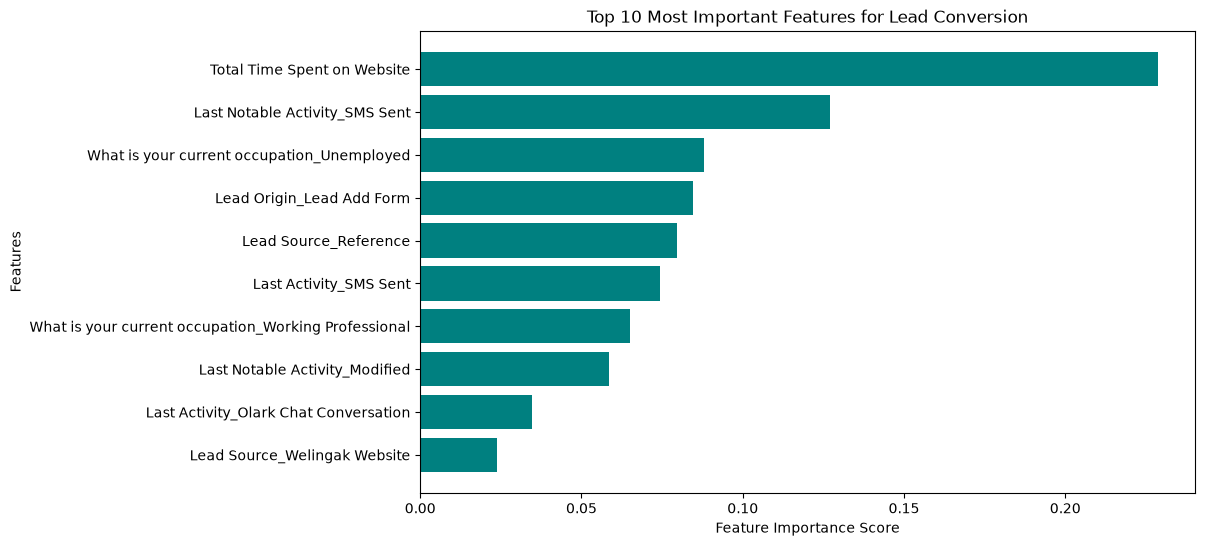

In [7]:
# Step 4: Feature Importance Visualization
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the trained model
importances = model.feature_importances_
feature_names = X.columns

# Create a dataframe for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='teal')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features for Lead Conversion')
plt.show()

# Saving the model & creating the Prediction Pipeline

In [8]:
# Step 5: Saving the Model for Deployment / Future Use
import joblib

# 1. Save the trained model to your local folder
joblib.dump(model, 'lead_scoring_model.pkl')
print("Model saved successfully as 'lead_scoring_model.pkl'!")

# 2. Demonstration of how to load the model and predict for a new lead later:
loaded_model = joblib.load('lead_scoring_model.pkl')

# Let's test it on the first row of your test dataset
sample_pred = loaded_model.predict(X_test.iloc[[0]])
print("\nSample Lead Prediction (1 = Converted, 0 = Not Converted):", sample_pred[0])

Model saved successfully as 'lead_scoring_model.pkl'!

Sample Lead Prediction (1 = Converted, 0 = Not Converted): 0
